In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math,copy

In [2]:
def sigmoid(z):
    return 1/(1+np.exp(-z))
    

In [3]:
def compute_cost_logistic(X,y,w,b,lambda_=1):

    m,n=X.shape

    cost=0
    for i in range(m):
        z=np.dot(w,X[i])+b
        f_wb_i=sigmoid(z)
        f_wb_i = np.clip(f_wb_i, 1e-15, 1 - 1e-15)  
        cost+=y[i]*np.log(f_wb_i)+(1-y[i])*np.log(1-f_wb_i)
    cost=cost/m

    reg_c=0
    for j in range(n):
        reg_c+=w[j]**2

    reg_c=(reg_c)*(lambda_/(2*m))

        
    return -cost+reg_c
    
        

In [4]:
def normalize(X):
    mu=np.mean(X,axis=0)
    sigma=np.std(X,axis=0)
    X_norm=(X-mu)/sigma

    return X_norm,mu,sigma

In [5]:
import numpy as np

X = np.array([
    [0.5, 3.0],
    [1.0, 2.5],
    [1.5, 3.2],
    [1.0, 1.0],
    [0.5, 0.5],
    [1.5, 1.0],
    [0.7, 2.0],
    [3.0, 3.0],
    [3.5, 3.5],
    [3.0, 1.0],
    [2.5, 0.5],
    [3.5, 1.5],
    [1.0, 2.8],
    [3.2, 0.7],
])

y = np.array([0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1])

In [6]:
def map_feature(X1, X2, degree=6):
    """
    Maps two features to polynomial features up to the given degree.
    Returns array with columns: X1, X2, X1^2, X1*X2, X2^2, X1^3, ..., X2^degree
    """
    X1 = X1.reshape(-1)
    X2 = X2.reshape(-1)
    out = []
    for i in range(1, degree + 1):
        for j in range(i + 1):
            out.append((X1**(i-j)) * (X2**j))
    return np.stack(out, axis=1)

X1 = X[:, 0]
X2 = X[:, 1]
X_f = map_feature(X1, X2, degree=6)
X_f

array([[5.00000000e-01, 3.00000000e+00, 2.50000000e-01, 1.50000000e+00,
        9.00000000e+00, 1.25000000e-01, 7.50000000e-01, 4.50000000e+00,
        2.70000000e+01, 6.25000000e-02, 3.75000000e-01, 2.25000000e+00,
        1.35000000e+01, 8.10000000e+01, 3.12500000e-02, 1.87500000e-01,
        1.12500000e+00, 6.75000000e+00, 4.05000000e+01, 2.43000000e+02,
        1.56250000e-02, 9.37500000e-02, 5.62500000e-01, 3.37500000e+00,
        2.02500000e+01, 1.21500000e+02, 7.29000000e+02],
       [1.00000000e+00, 2.50000000e+00, 1.00000000e+00, 2.50000000e+00,
        6.25000000e+00, 1.00000000e+00, 2.50000000e+00, 6.25000000e+00,
        1.56250000e+01, 1.00000000e+00, 2.50000000e+00, 6.25000000e+00,
        1.56250000e+01, 3.90625000e+01, 1.00000000e+00, 2.50000000e+00,
        6.25000000e+00, 1.56250000e+01, 3.90625000e+01, 9.76562500e+01,
        1.00000000e+00, 2.50000000e+00, 6.25000000e+00, 1.56250000e+01,
        3.90625000e+01, 9.76562500e+01, 2.44140625e+02],
       [1.50000000e+00

In [7]:
def plot_data(X, y):
    # Separate the classes
    X_pos = X[y == 1]
    X_neg = X[y == 0]

    # Positive examples
    plt.scatter(
        X_pos[:, 0], X_pos[:, 1],
        marker='x',
        s=180,
        color='red',
        linewidths=4,
        label='y=1'
    )

    # Negative examples
    plt.scatter(
        X_neg[:, 0], X_neg[:, 1],
        marker='o',
        s=180,
        facecolors='none',
        edgecolors='dodgerblue',
        linewidths=3,
        label='y=0'
    )

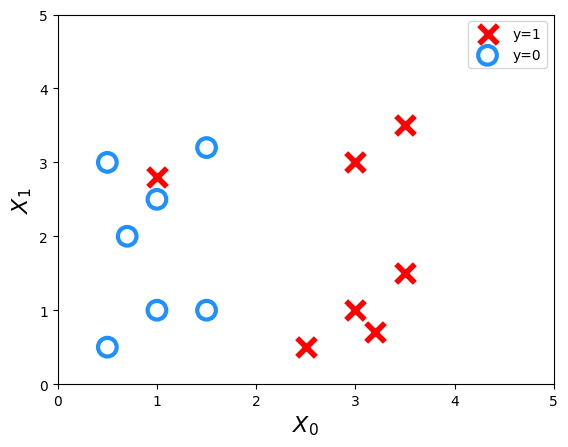

In [8]:
plot_data(X, y)
plt.xlabel(r'$X_0$', fontsize=16)
plt.ylabel(r'$X_1$', fontsize=16)

# Limits
plt.xlim(0,5)
plt.ylim(0,5)

# Legend
plt.legend()
plt.show()

In [9]:
def compute_gradients(X,y,w,b,lambda_=1):
    m,n=X.shape

    dj_dw=np.zeros(n)
    dj_db=0

    for i in range(m):
        f_wb_i=sigmoid(np.dot(w,X[i])+b)
        loss=f_wb_i-y[i]
        for j in range(n):
            dj_dw[j]=dj_dw[j]+loss*X[i,j]
        dj_db=dj_db+loss

    dj_dw=dj_dw/m
    dj_db=dj_db/m


    for j in range(n):
        dj_dw[j]+=w[j]*(lambda_/m)

    return dj_db,dj_dw

In [10]:
def gradient_descent(X,y,w_in,b_in,max_iters,alpha):
    J_history=[]
    w=copy.deepcopy(w_in)
    b=b_in
    for i in range(max_iters):
        dj_db,dj_dw=compute_gradients(X,y,w,b)

        w=w-alpha*dj_dw
        b=b-alpha*dj_db

        J_history.append(compute_cost_logistic(X,y,w,b))

        if i%math.ceil(max_iters/10)==0:
            print(f'Iteration{i:4d} cost{J_history[-1]}')

    return w,b,J_history

In [11]:
w_in=np.zeros(X_f.shape[1])
b_in=0
max_iters=10000
alpha=0.001
X_n=normalize(X_f)[0]
w_out,b_out,J_history=gradient_descent(X_n,y,w_in,b_in,max_iters,alpha)
w_out

Iteration   0 cost0.6915160945936327
Iteration1000 cost0.37294659344724906
Iteration2000 cost0.34085783993171065
Iteration3000 cost0.32976395095233535
Iteration4000 cost0.3237348929652476
Iteration5000 cost0.31965924453276345
Iteration6000 cost0.3166294204145508
Iteration7000 cost0.3142836338843033
Iteration8000 cost0.31243201437553186
Iteration9000 cost0.3109535863081506


array([ 0.50708834, -0.01073138,  0.44859072,  0.11328661,  0.02197601,
        0.38876791,  0.11281916,  0.02841125,  0.01675455,  0.33075037,
        0.10358498,  0.02063976,  0.00172454, -0.00674827,  0.27730601,
        0.09090954,  0.01987109, -0.0054354 , -0.01691092, -0.03601702,
        0.23023875,  0.07625376,  0.01798701, -0.00377632, -0.0181852 ,
       -0.03285472, -0.06459512])

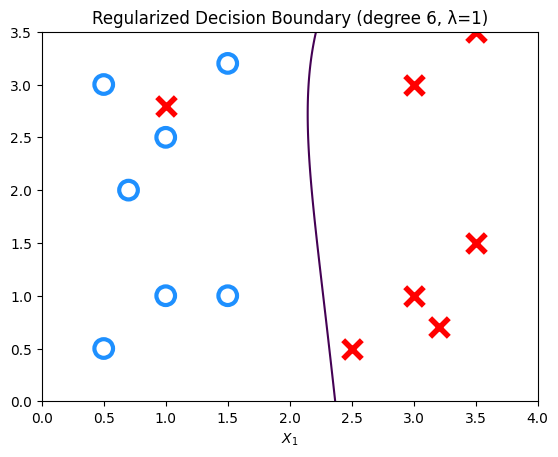

In [28]:
u=np.linspace(0,4,200)
v=np.linspace(0,3.5,200)
U,V=np.meshgrid(u,v)

mu=np.mean(X_f,axis=0)
sigma=np.std(X_f,axis=0)

Z=np.zeros_like(U)
for i in range(len(u)):
    for j in range(len(v)):
        feat=map_feature(np.array([U[i,j]]),np.array([V[i,j]]),degree=6)
        feat_n=(feat-mu)/sigma
        feat_n=feat_n.reshape(-1)
        z=w_out@feat_n+b_out
        Z[i,j]=sigmoid(z)


plot_data(X,y)
plt.contour(U,V,Z,levels=[0.5])
plt.xlabel(r'$X_0$')
plt.xlabel(r'$X_1$')
plt.xlim(0,4)
plt.ylim(0,3.5)
plt.title('Regularized Decision Boundary (degree 6, λ=1)')
plt.show()
